#Task 8: Semantic Segmentation Pipeline on Pixel-wise Grids using custom Dice Loss
# Objective:
 Construct high-precision spatial localization engines for medical imaging and
autonomous navigation datasets, utilizing advanced boundary overlap losses.
#Required Tech Stack:
 PyTorch, TorchVision, Albumentations, Matplotlib.
#Task Description:
Build a deep U-Net architecture for segmenting complex image masks.
Students must implement a custom composite loss function combining Soft Dice Loss and
Binary Cross-Entropy, write dataset pipelines parsing large spatial target masks, and plot
pixel-wise precision-recall boundary curves.

Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Download Dataset

In [2]:
image_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.PILToTensor()
])

train_dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

100%|██████████| 792M/792M [00:30<00:00, 26.0MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.74MB/s]


Custom Dataset Wrapper

In [3]:
class PetDataset(torch.utils.data.Dataset):

    def __init__(self,dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self,idx):

        image,mask = self.dataset[idx]

        mask = (mask > 1).float()

        return image,mask

DataLoader

In [4]:
dataset = PetDataset(train_dataset)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

images,masks = next(iter(loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 3, 128, 128])
torch.Size([8, 1, 128, 128])


U-Net Model

In [5]:
class DoubleConv(nn.Module):

    def __init__(self,in_ch,out_ch):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch,out_ch,3,padding=1),
            nn.ReLU(inplace=True)

        )

    def forward(self,x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128,256)

        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            2,
            stride=2
        )

        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            2,
            stride=2
        )

        self.conv2 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        c1 = self.down1(x)

        p1 = self.pool1(c1)

        c2 = self.down2(p1)

        p2 = self.pool2(c2)

        bridge = self.bridge(p2)

        up = self.up1(bridge)

        up = torch.cat([up,c2],dim=1)

        up = self.conv1(up)

        up = self.up2(up)

        up = torch.cat([up,c1],dim=1)

        up = self.conv2(up)

        return self.final(up)

Dice Loss

In [6]:
class DiceLoss(nn.Module):

    def forward(self,pred,target):

        pred = torch.sigmoid(pred)

        smooth = 1

        intersection = (pred * target).sum()

        union = pred.sum() + target.sum()

        dice = (2 * intersection + smooth) / (union + smooth)

        return 1 - dice

Combined Loss

In [7]:
bce = nn.BCEWithLogitsLoss()
dice = DiceLoss()

def combined_loss(pred,target):

    return bce(pred,target) + dice(pred,target)

Training

In [8]:
model = UNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

losses = []

for epoch in range(5):

    total = 0

    model.train()

    for images,masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        output = model(images)

        loss = combined_loss(
            output,
            masks
        )

        loss.backward()

        optimizer.step()

        total += loss.item()

    losses.append(total)

    print(
        f"Epoch {epoch+1} Loss {total:.4f}"
    )

Epoch 1 Loss 353.2150
Epoch 2 Loss 304.9082
Epoch 3 Loss 296.3924
Epoch 4 Loss 288.2943
Epoch 5 Loss 258.0365


Dice Score & IoU

In [9]:
def metrics(pred,target):

    pred = (torch.sigmoid(pred) > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    dice = (2 * intersection) / (union + 1e-8)

    iou = intersection / (
        pred.sum() +
        target.sum() -
        intersection +
        1e-8
    )

    return dice.item(), iou.item()

images,masks = next(iter(loader))

images = images.to(device)
masks = masks.to(device)

pred = model(images)

dice_score, iou = metrics(pred,masks)

print("Dice:",dice_score)
print("IoU :",iou)

Dice: 0.8980808854103088
IoU : 0.8150152564048767


Visualization

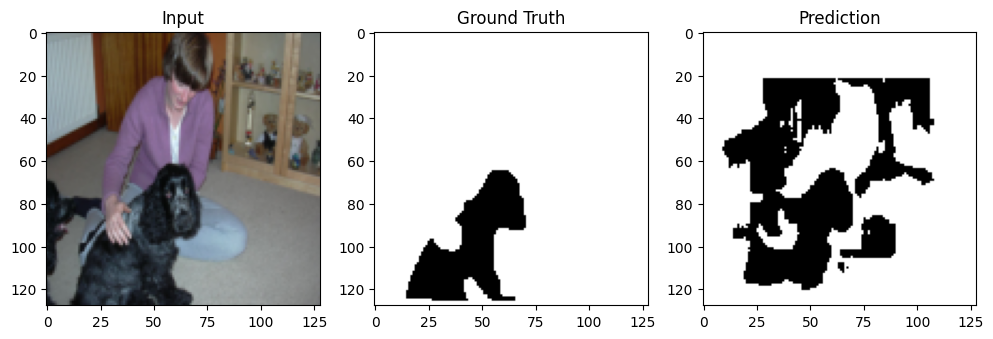

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[0].cpu().permute(1,2,0))
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(masks[0][0].cpu(),cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(
    (torch.sigmoid(pred[0][0])>0.5).cpu(),
    cmap="gray"
)
plt.title("Prediction")

plt.show()